# Summary: equivalent SDOF vs 3D NLTHA, all archetypes

1. **Peak displacements**: RE = median SDOF peak / median 3D peak (braced nodes) per intensity level, for the
   9 archetypes in both directions (top row X, bottom row Y).
2. **Displaced shapes**: 3D NLTHA mean shape vs the shape of the proposed model (equivalent static procedure)
   for the archetypes in `SHAPE_MODELS`, with the analysed line in the inset.

Data and helpers as in the per-archetype notebooks ([nltha_comparison.py](nltha_comparison.py)). IMs the SDOF
analyses have not reached yet are left out; rerun to update. Figures are saved to `FIG_DIR`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from nltha_comparison import (peak_comparison, load_geometry, static_shape, nltha_shape, IMS, _median,
                              collapsed_3d_median)

mpl.rc('font', family='Times New Roman')
mpl.rc('mathtext', fontset='stix')
%matplotlib inline

In [2]:
GROUPS       = [['M01', 'M02', 'M03'], ['M29', 'M30', 'M31'], ['M61', 'M62', 'M63']]
MODELS       = [m for g in GROUPS for m in g]
ARCHETYPE    = {m: k + 1 for k, m in enumerate(MODELS)}     # archetype number in the paper

SA_RATIO     = np.array([0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0])   # Sa(Ty,bldg)/Say,bldg of IM1-IM10
SDOF_FACTOR  = 'gamma_phi'  # SDOF -> braced-node displacement: 'gamma_phi', a number, or {'X': .., 'Y': ..}
DC_TARGET    = 12.0         # 2D pushover step (mm) of the SDOF calibration and of the static shape

SHAPE_MODELS = ['M02', 'M30', 'M62']
SHAPE_IM     = 7            # intensity level (1-10) of the NLTHA mean shapes
AMP_FILL     = 0.9          # default amplification: this fraction of the largest one that keeps the shapes inside the axes and clear of the inset
AMP          = {}           # amplification (m per unit) per model and direction, e.g. {'M02': {'X': 8.0}}; overrides AMP_FILL
LIMITS       = {            # (xlim, ylim) in m of each column, as in the paper figure
    'M02': ((-15, 45), (-10, 50)),
    'M30': ((-5, 35), (-10, 20)),
    'M62': ((-10, 100), (-20, 120)),
}
GEOM_TOP     = 0.62         # models not in LIMITS: fraction of the panel height filled by the geometry
INSET_RIGHT  = 0.97         # inset right edge, bottom edge and size, in fractions of the panel (same in all panels)
INSET_Y0     = 0.67
INSET_HEIGHT = 0.29
INSET_WIDTH  = {'X': 0.45, 'Y': 0.8}    # top row (X) and bottom row (Y)
# inset axis limits: (min, max), None for automatic, 'tight' for the extent of the plotted line,
# or a dictionary per model, e.g. {'M02': (0.6, 1.2), 'M30': (0.9, 1.2), 'M62': (0.9, 1.8)}
INSET_XLIM_X = {'M02': (0, 2), 'M30': (0.5, 1.5), 'M62': (0.75, 1.75)}        # top row (X):    x-axis = normalized displacement
INSET_YLIM_X = 'tight'     #                 y-axis = position along the line (m)
INSET_XLIM_Y = 'tight'     # bottom row (Y): x-axis = position along the line (m)
INSET_YLIM_Y = (0, 2)      #                 y-axis = normalized displacement

FIG_DIR      = 'C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Paper/Revision1'
os.makedirs(FIG_DIR, exist_ok=True)

## Peak displacements

In [3]:
comps = {m: peak_comparison(m, factor=SDOF_FACTOR, dc_target=DC_TARGET) for m in MODELS}
RE    = {m: {d: _median(c[d]['sdof']) / _median(c[d]['d3']) for d in 'XY'} for m, c in comps.items()}
COLL  = {m: {d: collapsed_3d_median(c, d) for d in 'XY'} for m, c in comps.items()}   # >= 50% of the 3D records collapsed

re_table = pd.DataFrame(
    [RE[m][d] for d in 'XY' for m in MODELS],
    index=pd.MultiIndex.from_tuples([(d, ARCHETYPE[m], m) for d in 'XY' for m in MODELS],
                                    names=['Direction', 'Archetype', 'Model']),
    columns=pd.Index(SA_RATIO, name='Sa/Say'))
re_table.round(2)

Sa/Say                     0.25  0.50  0.75  1.00  1.50  2.00  2.50  3.00  \
Direction Archetype Model                                                   
X         1         M01    1.13  1.17  1.19  1.21  1.20  1.17  1.20  1.18   
          2         M02    1.04  1.07  1.05  1.04  1.01  1.04  1.03  0.98   
          3         M03    0.96  0.96  0.93  0.93  0.86  0.52  1.00  1.00   
          4         M29    0.99  1.01  1.06  1.03  1.04  1.03  1.03  1.02   
          5         M30    1.01  1.03  1.01  1.02  1.04  1.02  1.03  0.99   
          6         M31    1.04  1.05  1.01  1.02  1.00  1.00  1.00  1.01   
          7         M61    1.04  1.05  1.02  1.06  1.05  1.03  1.07  1.04   
          8         M62    0.99  0.99  0.98  1.02  1.01  1.02  1.00  0.93   
          9         M63    0.85  0.90  0.90  0.93  0.89  0.82  0.36  0.44   
Y         1         M01    0.95  0.96  0.98  0.97  0.99  0.99  1.00  1.02   
          2         M02    0.83  0.91  0.92  0.93  0.94  0.93  0.94  0.91   
          3         M03    1.03  1.01  1.06  1.07  0.90  0.33  1.00  1.00   
          4         M29    0.71  0.93  0.92  0.99  0.98  0.96  0.99  0.98   
          5         M30    1.79  1.13  1.18  1.14  1.09  1.15  1.13  1.22   
          6         M31    1.23  1.06  0.97  1.03  0.98  1.06  1.01  1.11   
          7         M61    1.06  1.14  1.12  1.17  1.13  1.13  1.16  1.16   
          8         M62    1.00  1.03  1.04  1.09  1.09  1.06  1.08  0.99   
          9         M63    1.13  1.12  1.18  1.16  1.15  1.08  0.46  0.48   

Sa/Say                     3.50  4.00  
Direction Archetype Model              
X         1         M01    1.19  1.19  
          2         M02    0.97  0.97  
          3         M03    1.00  1.00  
          4         M29    1.02  1.05  
          5         M30    1.03  1.02  
          6         M31    1.03  1.01  
          7         M61    1.05  1.10  
          8         M62    0.86  0.32  
          9         M63    1.00  1.00  
Y         1         M01    1.01  0.99  
          2         M02    0.88  0.88  
          3         M03    1.00  1.00  
          4         M29    0.99  0.96  
          5         M30    1.22  1.15  
          6         M31    1.04  1.08  
          7         M61    1.15  1.11  
          8         M62    0.68  0.33  
          9         M63    1.00  1.00

In [4]:
rows = []
for d in 'XY':
    for m in MODELS:
        # RE statistics over the IMs whose 3D median is not a collapse
        re = RE[m][d][~np.isnan(RE[m][d]) & ~COLL[m][d]]
        rows.append(dict(Direction=d, Archetype=ARCHETYPE[m], Model=m,
                         **{'SDOF factor': comps[m][d]['factor'], 'IMs': len(re), 'IMs 3D collapsed': int(COLL[m][d].sum()),
                            'RE median': np.median(re), 'RE min': re.min(), 'RE max': re.max(),
                            '|RE-1| <= 10%': np.mean(np.abs(re - 1) <= 0.1),
                            '|RE-1| <= 20%': np.mean(np.abs(re - 1) <= 0.2)}))
summary = pd.DataFrame(rows).set_index(['Direction', 'Archetype', 'Model'])
summary.style.format({'SDOF factor': '{:.3f}', 'RE median': '{:.2f}', 'RE min': '{:.2f}', 'RE max': '{:.2f}',
                      '|RE-1| <= 10%': '{:.0%}', '|RE-1| <= 20%': '{:.0%}'})

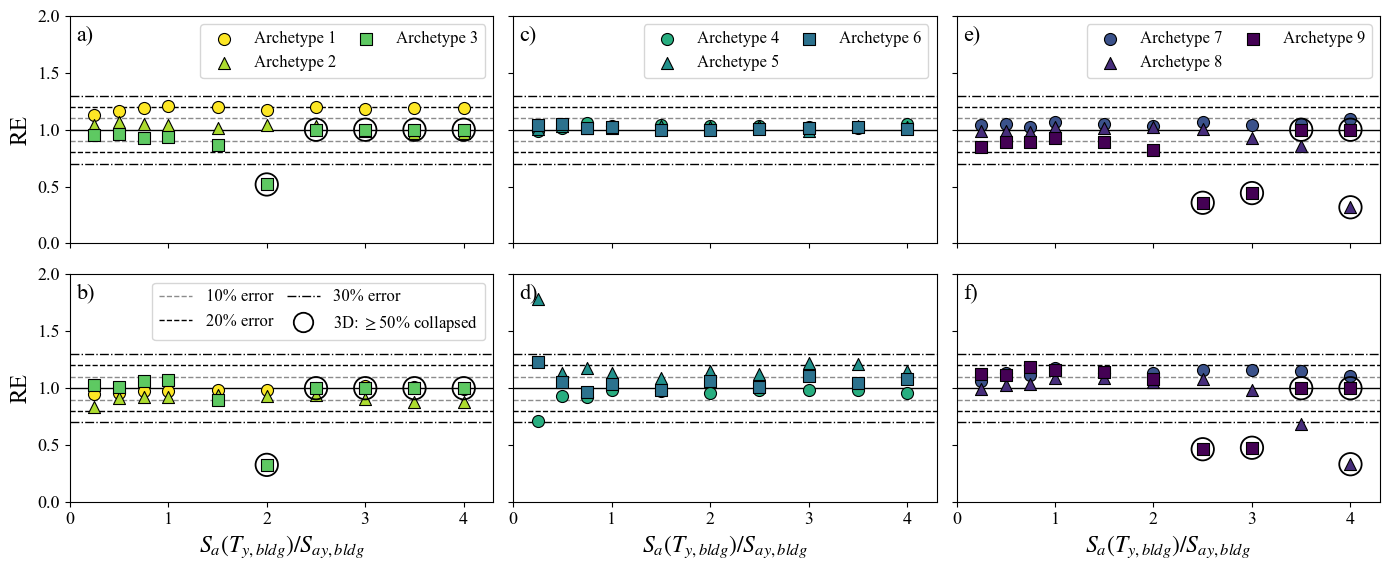

In [5]:
colors  = plt.cm.viridis(np.linspace(1, 0, len(MODELS)))   # archetype 1 yellow ... 9 purple
markers = ['o', '^', 's']
bands   = [(0.1, '--', '0.55', '10% error'), (0.2, '--', 'k', '20% error'), (0.3, '-.', 'k', '30% error')]

fig, axs = plt.subplots(2, 3, figsize=(14, 5.8), sharex=True, sharey=True)
for col, group in enumerate(GROUPS):
    for row, d in enumerate('XY'):
        ax = axs[row, col]
        band_handles = []
        for b, ls, c, lab in bands:
            band_handles.append(ax.axhline(1 + b, ls=ls, color=c, lw=1, label=lab))
            ax.axhline(1 - b, ls=ls, color=c, lw=1)
        ax.axhline(1, color='k', lw=1)
        for k, m in enumerate(group):
            ax.scatter(SA_RATIO, RE[m][d], marker=markers[k], s=75, color=colors[ARCHETYPE[m] - 1],
                       edgecolor='k', lw=0.8, zorder=3, label=f'Archetype {ARCHETYPE[m]}')
        for m in group:   # circle the IMs where at least half of the 3D records collapsed
            c3 = COLL[m][d]
            ax.scatter(SA_RATIO[c3], RE[m][d][c3], marker='o', s=260, facecolors='none',
                       edgecolors='k', lw=1.3, zorder=4)
        ax.text(0.015, 0.96, f'{chr(ord("a") + 2 * col + row)})', transform=ax.transAxes, va='top', fontsize=16)
        if row == 0:
            ax.legend(handles=ax.collections[:3], ncol=2, fontsize=12, loc='upper right', columnspacing=0.8)
        elif col == 0:
            coll_handle = Line2D([], [], marker='o', ls='', ms=14, mfc='none', mec='k', mew=1.3,
                                 label=r'3D: $\geq$50% collapsed')
            ax.legend(handles=band_handles + [coll_handle], ncol=2, fontsize=12, loc='upper right', columnspacing=0.8)
        ax.tick_params(labelsize=13)

for ax in axs[:, 0]:
    ax.set_ylabel('RE', fontsize=17)
for ax in axs[-1]:
    ax.set_xlabel(r'$S_a(T_{y,bldg})/S_{ay,bldg}$', fontsize=17)
axs[0, 0].set_xlim(0, 4.3)
axs[0, 0].set_ylim(0, 2)
axs[0, 0].set_xticks(range(5))
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'RE_peak_displacements.png'), dpi=300, bbox_inches='tight')
plt.show()

## Displaced shapes

Plan of each archetype with the 3D NLTHA mean shape at `SHAPE_IM` ($\mu_{NLTHA}$) and the shape of the
proposed model at the pushover step closest to `DC_TARGET` ($\Delta_{critical}$), both normalized to 1 at
the reference node of the 2D model and amplified for display. Ticks mark the transverse restraints (braced
nodes) in the direction of the excitation. Inset: normalized displacement along the analysed line (first
line of `nltha_lines` where the 2D model has two).

M02x: NLTHA IM7 (44 records), mean peak 19.3 mm, static at dc = 12.3 mm, amplification 6.21 m
M02y: NLTHA IM7 (44 records), mean peak 17.4 mm, static at dc = 12.3 mm, amplification 5.58 m
M30x: NLTHA IM7 (44 records), mean peak 11.1 mm, static at dc = 12.3 mm, amplification 2.56 m


M30y: NLTHA IM7 (44 records), mean peak 11.4 mm, static at dc = 12.3 mm, amplification 1.55 m
M62x: NLTHA IM7 (42 records), mean peak 23.9 mm, static at dc = 12.3 mm, amplification 7.63 m


M62y: NLTHA IM7 (42 records), mean peak 24.3 mm, static at dc = 12.3 mm, amplification 7.02 m


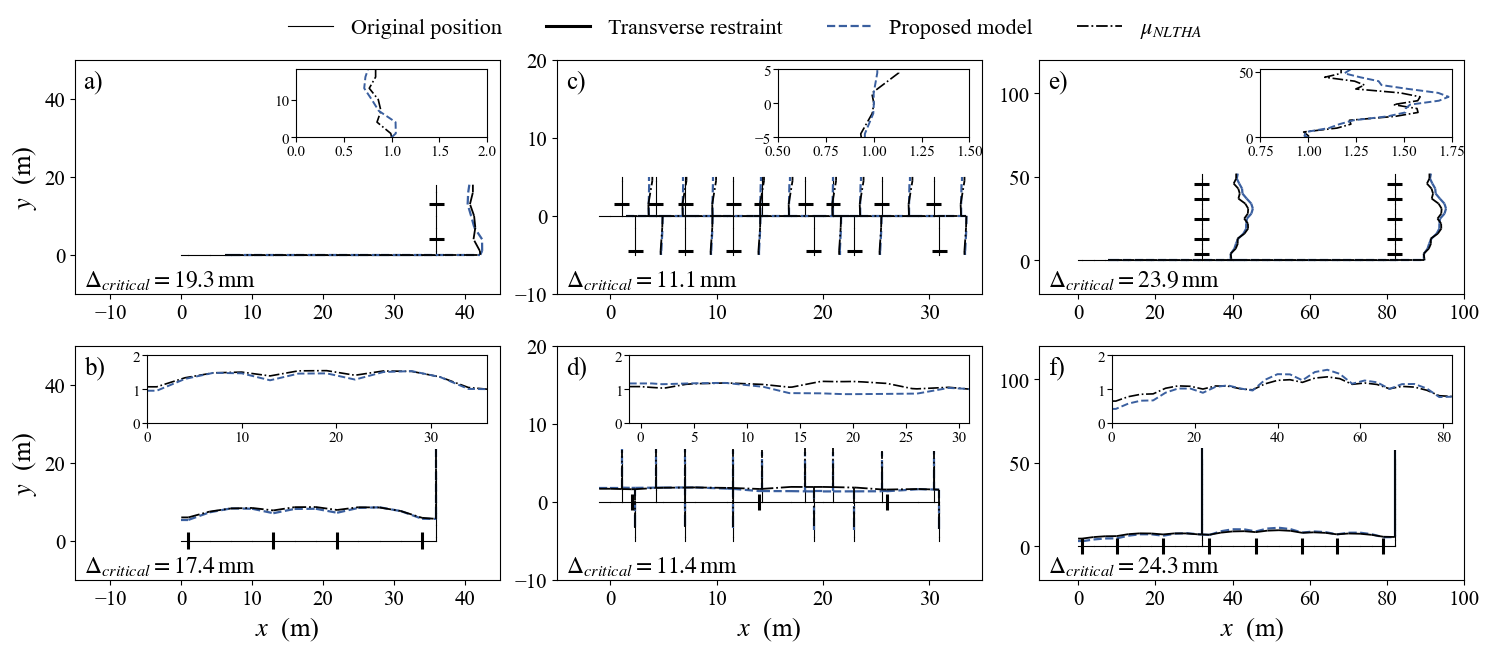

In [6]:
from nltha_comparison import load_3d_peaks

C_PROP = '#3a5f9f'

def shape_data(m, d):
    geom = load_geometry(m)
    st   = static_shape(m, d, geom, DC_TARGET)
    mu, _, n = nltha_shape(m, d, SHAPE_IM, st['i_ref'])
    peak = np.nanmean(load_3d_peaks(m, d)[:, SHAPE_IM - 1])   # mean 3D peak (braced nodes) of the same records
    e    = np.array([1.0, 0.0]) if d == 'X' else np.array([0.0, 1.0])
    return dict(m=m, d=d, geom=geom, st=st, mu=mu, n=n, e=e, peak=peak)


def column_limits(data):
    # Limits of a column not in LIMITS: the geometry fills the height from 12 % (room for the
    # Delta_critical label) to GEOM_TOP, leaving the top for the inset
    pts = np.vstack([D['geom']['xy'] for D in data])
    (x0, y0), (x1, y1) = pts.min(axis=0), pts.max(axis=0)
    w = x1 - x0
    y1 = max(y1, y0 + 0.12 * w)
    R = (y1 - y0) / (GEOM_TOP - 0.12)
    return (x0 - 0.1 * w, x1 + 0.2 * w), (y0 - 0.12 * R, y0 + 0.88 * R)


def inset_position(d):
    return [INSET_RIGHT - INSET_WIDTH[d], INSET_Y0, INSET_WIDTH[d], INSET_HEIGHT]


def fit_amp(D, xlim, ylim):
    # Largest amplification keeping both displaced shapes inside the axes and clear of the inset
    # (and its tick labels), times AMP_FILL
    xy, k = D['geom']['xy'], (0 if D['d'] == 'X' else 1)     # k: axis of the excitation
    t     = 1 - k
    lo    = np.array([xlim[0], ylim[0]])
    span  = np.array([xlim[1] - xlim[0], ylim[1] - ylim[0]])
    f     = (xy - lo) / span                                  # node positions in axes fractions
    x0, y0, w, h = inset_position(D['d'])
    box_lo, box_hi = np.array([x0 - 0.07, y0 - 0.1]), np.array([x0 + w, y0 + h])
    bound = np.full(len(xy), 0.97)
    below = (f[:, t] > box_lo[t]) & (f[:, t] < box_hi[t]) & (f[:, k] < box_lo[k])
    bound[below] = box_lo[k]
    v  = np.maximum(D['mu'], D['st']['phi'])
    ok = v > 1e-6
    return AMP_FILL * np.min((bound[ok] - f[ok, k]) * span[k] / v[ok])


def draw_panel(ax, D, xlim, ylim):
    d, xy, edges, e, amp = D['d'], D['geom']['xy'], D['geom']['edges'], D['e'], D['amp']
    for v, kw in [(np.zeros(len(xy)), dict(color='k', lw=0.8)),
                  (D['st']['phi'], dict(color=C_PROP, ls='--', lw=1.6)),
                  (D['mu'], dict(color='k', ls='-.', lw=1.3))]:
        for i, j in edges:
            ax.plot(*np.array([xy[i] + amp * v[i] * e, xy[j] + amp * v[j] * e]).T, **kw)

    # Transverse restraints: ticks along the excitation, centred on the braced nodes of the pipes
    # that run across it (restraints on pipes parallel to the excitation are longitudinal)
    L = 0.035 * (xlim[1] - xlim[0]) if d == 'X' else 0.07 * (ylim[1] - ylim[0])
    for i in D['geom']['braced'][d]:
        along = [xy[j] - xy[i] for a, b in edges if i in (a, b) for j in (a, b) if j != i]
        if any(abs(v @ e) > 0.9 * np.linalg.norm(v) for v in along):
            continue
        ax.plot(*np.array([xy[i] - L / 2 * e, xy[i] + L / 2 * e]).T, color='k', lw=2.2, solid_capstyle='butt')

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.text(0.02, 0.03, rf'$\Delta_{{critical}} = {D["peak"]:.1f}\,\mathrm{{mm}}$', transform=ax.transAxes,
            fontsize=17)

    # Inset: normalized displacement along the analysed line
    idx = D['st']['lines'][0][1]
    s   = xy[idx] @ (np.array([0.0, 1.0]) if d == 'X' else np.array([1.0, 0.0]))
    o   = np.argsort(s)
    ins = ax.inset_axes(inset_position(d))
    if d == 'X':
        ins.plot(D['mu'][idx][o], s[o], 'k-.', lw=1.2)
        ins.plot(D['st']['phi'][idx][o], s[o], ls='--', color=C_PROP, lw=1.4)
    else:
        ins.plot(s[o], D['mu'][idx][o], 'k-.', lw=1.2)
        ins.plot(s[o], D['st']['phi'][idx][o], ls='--', color=C_PROP, lw=1.4)
    xlim, ylim = (INSET_XLIM_X, INSET_YLIM_X) if d == 'X' else (INSET_XLIM_Y, INSET_YLIM_Y)
    xlim, ylim = [lim.get(D['m']) if isinstance(lim, dict) else lim for lim in (xlim, ylim)]
    for lim, axis, set_lim in ((xlim, 'x', ins.set_xlim), (ylim, 'y', ins.set_ylim)):
        if isinstance(lim, str) and lim == 'tight':
            data = np.concatenate([l.get_xdata() if axis == 'x' else l.get_ydata() for l in ins.lines])
            set_lim(data.min(), data.max())
        elif lim is not None:
            set_lim(*lim)
    ins.tick_params(labelsize=11, pad=1.5)


fig, axs = plt.subplots(2, 3, figsize=(15, 6.6))
for col, m in enumerate(SHAPE_MODELS):
    data = {d: shape_data(m, d) for d in 'XY'}
    xlim, ylim = LIMITS[m] if m in LIMITS else column_limits(data.values())
    for row, d in enumerate('XY'):
        D = data[d]
        D['amp'] = AMP.get(m, {}).get(d) or fit_amp(D, xlim, ylim)
        ax = axs[row, col]
        draw_panel(ax, D, xlim, ylim)
        ax.text(0.02, 0.96, f'{chr(ord("a") + 2 * col + row)})', transform=ax.transAxes, va='top', fontsize=18)
        ax.tick_params(labelsize=15)
        print(f'{m}{d.lower()}: NLTHA IM{SHAPE_IM} ({D["n"]} records), mean peak {D["peak"]:.1f} mm, static at dc = {D["st"]["dc"]:.1f} mm, '
              f'amplification {D["amp"]:.2f} m')

for ax in axs[:, 0]:
    ax.set_ylabel(r'$y$  (m)', fontsize=19)
for ax in axs[-1]:
    ax.set_xlabel(r'$x$  (m)', fontsize=19)

fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.legend(handles=[Line2D([], [], color='k', lw=0.8, label='Original position'),
                    Line2D([], [], color='k', lw=2.2, label='Transverse restraint'),
                    Line2D([], [], color=C_PROP, ls='--', lw=1.6, label='Proposed model'),
                    Line2D([], [], color='k', ls='-.', lw=1.3, label=r'$\mu_{NLTHA}$')],
           loc='upper center', ncol=4, fontsize=16, frameon=False, bbox_to_anchor=(0.5, 1.0))
fig.savefig(os.path.join(FIG_DIR, 'Figure10.tiff'), dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# Mean relative error of the proposed shape vs the NLTHA mean shape, per panel of the figure:
# |phi - mu| / |mu| averaged over the nodes of the analysed line (inset) and over all DispShape
# nodes (plan), excluding the normalization node (error 0 by construction)
def shape_errors(D):
    mu, phi, i_ref = D['mu'], D['st']['phi'], D['st']['i_ref']
    out = {}
    for name, idx in (('line', D['st']['lines'][0][1]), ('all nodes', np.arange(len(mu)))):
        idx = np.array([i for i in idx if i != i_ref and abs(mu[i]) > 1e-6])
        r   = np.abs(phi[idx] - mu[idx]) / np.abs(mu[idx])
        out[(name, 'mean')], out[(name, 'max')], out[(name, 'nodes')] = r.mean(), r.max(), len(idx)
    return out

rows = {}
for m in SHAPE_MODELS:
    for d in 'XY':
        D = shape_data(m, d)
        rows[(m, d)] = {('', 'NLTHA records'): D['n'], ('', 'dc (mm)'): D['st']['dc'], **shape_errors(D)}

shape_err = pd.DataFrame.from_dict(rows, orient='index')
shape_err.columns = pd.MultiIndex.from_tuples(shape_err.columns)
shape_err.index.names = ['Model', 'Direction']
shape_err.loc[('Average', ''), :] = shape_err.mean()
pct = {c: '{:.1%}' for c in shape_err.columns if c[1] in ('mean', 'max')}
shape_err.style.format(pct).format('{:.0f}', subset=[c for c in shape_err.columns if c[1] in ('nodes', 'NLTHA records')]).format('{:.1f}', subset=[('', 'dc (mm)')])